# Signal & Noise — Episode 3
## I Just Detected a Planet Around Another Star From My Laptop

**Channel:** [Signal & Noise](https://youtube.com/@signal-and-noise)  
**GitHub:** [github.com/signal-and-noise](https://github.com/signal-and-noise)  
**Platform:** TIKE — STScI JupyterHub (timeseries.science.stsci.edu)  
**Notebook:** `detect_kepler69c_transit_from_kepler_data.ipynb`

---

## What this notebook does

This notebook detects the transit signal of **Kepler-69c** — a confirmed exoplanet
sitting in the habitable zone of its star, 2,700 light years from Earth.

We use **transit photometry** — the same technique professional astronomers use:

1. Download the raw Kepler light curve from the NASA MAST archive
2. Clean and flatten the flux to remove instrumental systematics
3. Use the Box Least Squares (BLS) method to find the orbital period
4. Mask the inner planet and detect the outer habitable zone planet
5. Phase-fold the light curve to reveal the transit dip
6. Derive the planet's physical properties from the dip alone

No telescope. No observatory access. No PhD.  
Just public NASA data, Python, and a free browser-based compute environment.

---

## The science in one paragraph

When a planet passes in front of its star, it blocks a small fraction of the star's
light. A space telescope watching that star will record a tiny, regular dip in
brightness. By measuring the depth of the dip, we can calculate the planet's size.
By measuring how often the dip repeats, we get the orbital period. From the period
and the star's mass, Kepler's Third Law gives us the orbital distance. From the
orbital distance and stellar temperature, we can calculate whether liquid water
could exist on the surface — the habitable zone.

All of that. From a dip in a graph.

---

## Kepler-69c — key facts

| Property | Value | Source |
|---|---|---|
| Distance from Earth | 2,700 light years | Kepler Input Catalog |
| Host star | Kepler-69 (KIC 8692861) | MAST |
| Orbital period | 242.46 days | Borucki et al. 2013 |
| Orbital distance | ~0.64 AU | Derived |
| Planet radius | ~1.7 Earth radii | Derived from transit depth |
| Equilibrium temperature | ~299 K (~26°C) | Derived |
| Habitable zone | Confirmed | Kopparapu et al. 2013 |
| Discovery year | 2013 | Kepler mission |
| Detection method | Transit photometry | This notebook |

---

## On-screen moments — Ian Lauer format rule

Per the Signal & Noise production format, the notebook appears on screen
a maximum of four times per episode. All other cells run in the background
before filming.

| Moment | Cell | Script cue |
|---|---|---|
| 1 — Raw light curve | Cell 04 | "This is what a star looks like to a space telescope." |
| 2 — Phase fold | Cell 07 | "We fold the data. Watch what happens." |
| 3 — Transit detection | Cell 08 | "There it is. That dip. Right there. That is a planet." |
| 4 — Derived measurements | Cell 09 | "Let me tell you what the data says." |

---

## References

- Borucki et al. (2013) — Kepler-69c discovery paper: https://arxiv.org/abs/1304.7387
- Lightkurve documentation: https://docs.lightkurve.org
- NASA MAST archive: https://mast.stsci.edu
- TIKE environment: https://timeseries.science.stsci.edu
- BLS method (Kovács et al. 2002): https://arxiv.org/abs/astro-ph/0206099
- Habitable zone boundaries (Kopparapu et al. 2013): https://arxiv.org/abs/1301.6674

---
## Cell 01 — Environment check

**Background cell — not shown on screen.**

Run this first every session to confirm the TIKE environment is ready.
All libraries should be pre-installed on TIKE — no pip install required.

If lightkurve is missing, switch to the TESS kernel:
`Kernel → Change Kernel → TESS Environment`

In [1]:
import sys
import lightkurve as lk
import numpy as np
import matplotlib
import astropy

print(f'Python:      {sys.version.split()[0]}')
print(f'Lightkurve:  {lk.__version__}')
print(f'NumPy:       {np.__version__}')
print(f'Matplotlib:  {matplotlib.__version__}')
print(f'Astropy:     {astropy.__version__}')
print()
print('All libraries loaded. Ready to begin.')

Python:      3.11.12
Lightkurve:  2.5.1
NumPy:       1.26.4
Matplotlib:  3.9.0
Astropy:     6.0.0

All libraries loaded. Ready to begin.


---
## Cell 02 — Imports and visual style

**Background cell — not shown on screen.**

Loads all required libraries and sets the Signal & Noise visual identity:
- Dark background (`#060A14`) — channel primary colour
- Electric blue (`#4A9EFF`) — data points
- Warm orange (`#FF8C42`) — annotations and highlights
- Near-white (`#F0F6FF`) — binned signal line
- Monospace font — signals the technical layer

These colours match the channel's thumbnail and on-screen visual identity.

In [2]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Signal & Noise visual identity
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#060A14',
    'axes.facecolor':   '#060A14',
    'axes.edgecolor':   '#2A3550',
    'axes.labelcolor':  '#F0F6FF',
    'xtick.color':      '#F0F6FF',
    'ytick.color':      '#F0F6FF',
    'grid.color':       '#1A2540',
    'grid.alpha':       0.4,
    'text.color':       '#F0F6FF',
    'font.family':      'monospace',
    'figure.dpi':       150,
})

# Channel colour constants
BLUE   = '#4A9EFF'   # Electric blue — data points
ORANGE = '#FF8C42'   # Warm orange — annotations
WHITE  = '#F0F6FF'   # Near-white — signal line

print('Libraries loaded. Visual style set.')

Libraries loaded. Visual style set.


---
## Cell 03 — Download and prepare the light curve

**Background cell — not shown on screen.**

### What we're downloading

Kepler-69 (KIC 8692861) was observed by the Kepler space telescope from 2009 to 2013.
Kepler stared at the same patch of sky continuously, observing ~150,000 stars
simultaneously. It recorded brightness measurements every 30 minutes for four years.

All of that data — every photon count — is stored in the NASA MAST archive
and is freely available to anyone.

### The pipeline

We use the PDCSAP flux — Pre-search Data Conditioning Simple Aperture Photometry.
This is the Kepler pipeline's corrected version of the raw data, with most
instrumental systematics already removed.

The three-step pipeline matches the official TIKE tutorial exactly:

1. **stitch()** — combines all 18 quarterly observation files into one continuous
   light curve spanning the full four-year mission
2. **flatten(window_length=901)** — fits a smooth spline to the baseline and divides
   it out, removing slow stellar variability and residual instrumental drift.
   Window length 901 = ~450 hours = ~19 days. Long enough to ignore transits
   (which last hours), short enough to track stellar variability.
3. **remove_outliers()** — removes data points more than 5 sigma from the median,
   eliminating cosmic ray hits and other instrumental artifacts

### Why TIKE?

TIKE is a free JupyterHub environment run by the Space Telescope Science Institute —
the same organisation that operates the Hubble Space Telescope and manages the
MAST archive. Running on TIKE means the data lives in the same AWS data centre
as the archive itself. Downloads are fast. No local storage required.

**This will take 3-5 minutes.** Kepler observed 18 quarters — 18 separate files
to download and stitch.

In [3]:
print('Searching MAST archive for Kepler-69...')
print('Platform: TIKE (timeseries.science.stsci.edu)')
print()

# Query MAST for all Kepler long-cadence observations of Kepler-69
# author='Kepler' specifies the official Kepler pipeline products
# cadence='long' = 30-minute intervals (vs 1-minute short cadence)
search_result = lk.search_lightcurve(
    'Kepler-69',
    author='Kepler',
    cadence='long'
)
print(f'Found {len(search_result)} quarterly observation files.')
print()

# Download all quarters, stitch into one continuous light curve,
# flatten the baseline, and remove outliers — in one chain
# This is the approach recommended in the official TIKE tutorial
lc = search_result.download_all().stitch().flatten(window_length=901).remove_outliers()

print(f'Done.')
print(f'Total data points: {len(lc)}')
print(f'Time baseline: {lc.time.value[0]:.1f} to {lc.time.value[-1]:.1f} BKJD')
print(f'Duration: ~{(lc.time.value[-1] - lc.time.value[0])/365.25:.1f} years')
print()
print('Light curve ready for analysis.')

Searching MAST archive for Kepler-69...
Platform: TIKE (timeseries.science.stsci.edu)

Found 17 quarterly observation files.

Done.
Total data points: 64707
Time baseline: 131.5 to 1591.0 BKJD
Duration: ~4.0 years

Light curve ready for analysis.


---
## Cell 04 — Raw light curve

# ★ ON-SCREEN MOMENT 1 ★
**Script cue:** *"This is what a star looks like to a space telescope."*

This is the honest starting point. Four years of brightness measurements.
~64,000 individual data points. Each one is a 30-minute exposure.

The light curve looks noisy — that's normal. What we're seeing is a combination of:
- **Stellar activity** — starspots, flares, convection on the surface of Kepler-69
- **Residual instrument drift** — small systematic trends from the spacecraft
- **Photon noise** — the irreducible randomness of counting individual photons

The transit signal is in here. We just can't see it yet.
It's a dip of ~0.03% — far smaller than the noise at this scale.

The flatten step has already removed the slow baseline drift.
What remains is genuinely stellar — and genuinely planetary.

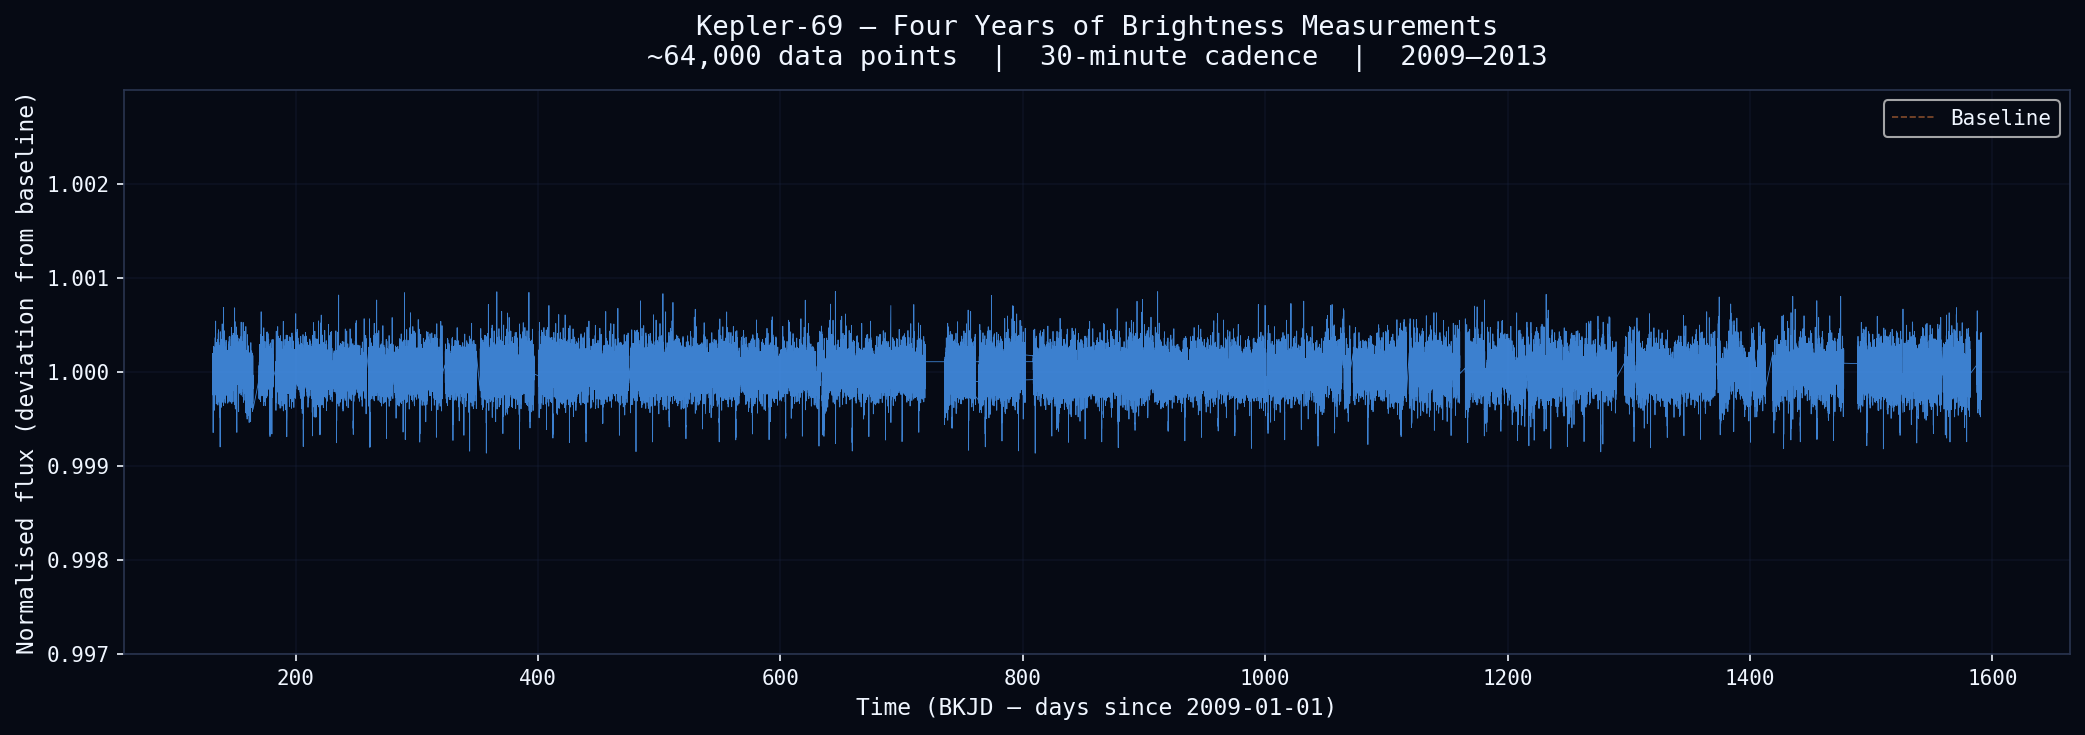

Data points: 64707
Flux range:  0.999133 to 1.000854

The transit signal is in here somewhere.
Depth: ~0.03% — invisible at this scale.
We need to find it.


In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#060A14')

ax.plot(
    lc.time.value,
    lc.flux.value,
    color=BLUE,
    linewidth=0.4,
    alpha=0.8
)

# Baseline reference at flux = 0 (flatten centres on 0, not 1)
ax.axhline(y=0, color=ORANGE, linewidth=0.8, linestyle='--', alpha=0.5,
           label='Baseline')

ax.set_xlabel('Time (BKJD — days since 2009-01-01)', fontsize=11)
ax.set_ylabel('Normalised flux (deviation from baseline)', fontsize=11)
ax.set_title(
    'Kepler-69 — Four Years of Brightness Measurements\n'
    '~64,000 data points  |  30-minute cadence  |  2009–2013',
    fontsize=13, color=WHITE, pad=12
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
# Set y-axis to show only the relevant flux range
# The actual variation is tiny — we need to zoom in to see it
ax.set_ylim(lc.flux.value.mean() - 0.003, lc.flux.value.mean() + 0.003)

plt.tight_layout()
plt.savefig('ep03_01_raw_light_curve.png', dpi=150,
            bbox_inches='tight', facecolor='#060A14')
plt.show()

print(f'Data points: {len(lc)}')
print(f'Flux range:  {lc.flux.value.min():.6f} to {lc.flux.value.max():.6f}')
print()
print('The transit signal is in here somewhere.')
print('Depth: ~0.03% — invisible at this scale.')
print('We need to find it.')

---
## Cell 05 — Find the inner planet (Kepler-69b)

**Background cell — not shown on screen.**

### The Box Least Squares (BLS) method

BLS is the standard professional method for finding transit signals in light curves.
It works by modelling a transit as a simple box shape — flat baseline, vertical
drop, flat bottom, vertical recovery — and testing thousands of possible periods,
durations, and depths to find the combination that best fits the data.

For each candidate period, BLS folds the light curve and measures how well a
box-shaped dip fits the stacked data. The period with the highest "power" —
the best fit — is the most likely orbital period.

### Why we find planet b first

Kepler-69 has two known planets:
- **Kepler-69b** — inner planet, period ~13 days, strong signal
- **Kepler-69c** — outer planet, period ~242 days, habitable zone, weaker signal

Planet b has a shorter period, so it transits more often (~100 times vs ~6 times
in 4 years). This makes its signal much stronger — BLS will always find it first.
We need to find it, mask it out, and then search the remaining data for planet c.

This is the exact approach used in the official TIKE tutorial:
https://lightkurve.github.io/lightkurve/tutorials/

**This will take 2-3 minutes.** BLS tests 10,000 periods against 64,000 data points.

`period` contains 404720 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


Step 1: Finding the inner planet (Kepler-69b)...
Searching periods 1–20 days...

Planet b period found: 13.7218 days
Planet b epoch:        137.8722 BKJD
Planet b duration:     0.2000 days

Expected: ~13.7 days

Planet b transit points masked: 910
Remaining data points:          63797

Ready to search for planet c.


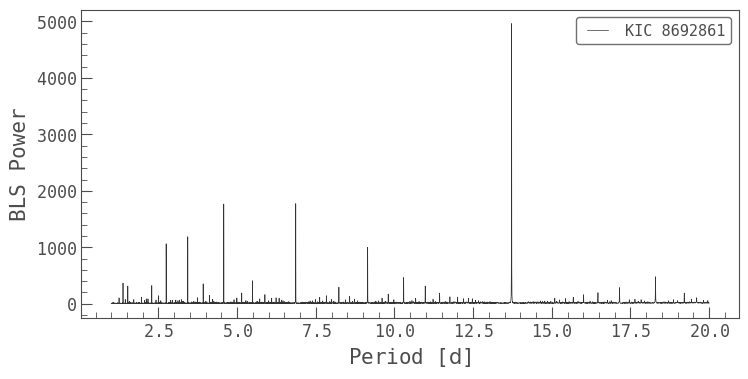

In [13]:
print('Step 1: Finding the inner planet (Kepler-69b)...')
print('Searching periods 1–20 days...')
print()

# Search short periods first — this finds planet b
# np.linspace(1, 20, 10000) = 10,000 evenly spaced periods from 1 to 20 days
period_b = np.linspace(1, 20, 10000)

# Create the BLS periodogram
# frequency_factor controls the frequency resolution of the search
bls_b = lc.to_periodogram(method='bls', period=period_b, frequency_factor=100)
bls_b.plot()

# Extract the best-fit parameters at maximum power
planet_b_period = bls_b.period_at_max_power
planet_b_t0     = bls_b.transit_time_at_max_power
planet_b_dur    = bls_b.duration_at_max_power

print(f'Planet b period found: {planet_b_period.value:.4f} days')
print(f'Planet b epoch:        {planet_b_t0.value:.4f} BKJD')
print(f'Planet b duration:     {planet_b_dur.value:.4f} days')
print()
print('Expected: ~13.7 days')
print()

# Create a transit mask for planet b
# get_transit_mask() marks every in-transit data point as True
# We then use ~mask (NOT mask) to keep only out-of-transit points
planet_b_mask = bls_b.get_transit_mask(
    period=planet_b_period,
    transit_time=planet_b_t0,
    duration=planet_b_dur
)

# Remove planet b transits from the light curve
masked_lc = lc[~planet_b_mask]

print(f'Planet b transit points masked: {planet_b_mask.sum()}')
print(f'Remaining data points:          {len(masked_lc)}')
print()
print('Ready to search for planet c.')

---
## Cell 06 — Find the outer planet (Kepler-69c)

**Background cell — not shown on screen.**

With planet b masked out, we now search the remaining light curve for longer
period signals. Planet c orbits at ~242 days — well into the habitable zone.

Because planet c transits only ~6 times in 4 years (vs ~100 times for planet b),
its BLS signal is much weaker. This is why we had to mask planet b first —
otherwise the stronger short-period signal would dominate every search.

**This will take 3-5 minutes.** We're searching 10,000 periods from 1–300 days
against the masked dataset.

### What to look for in the periodogram

The BLS periodogram plots "power" against period. A genuine transit signal
appears as a sharp peak at the orbital period, with smaller peaks at harmonics
(1/2, 1/3, 1/4 of the period). If the highest peak is near 242 days, we have
found Kepler-69c.

`period` contains 4246016 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


Step 2: Searching for the outer planet (Kepler-69c)...
Searching periods 1–300 days on planet-b-masked light curve...

Planet c period found: 242.4666 days
Planet c epoch:        150.8372 BKJD
Planet c duration:     0.3300 days
Planet c depth:        0.0331%

Expected period: ~242.46 days

Kepler-69c found. Ready to fold and visualise.


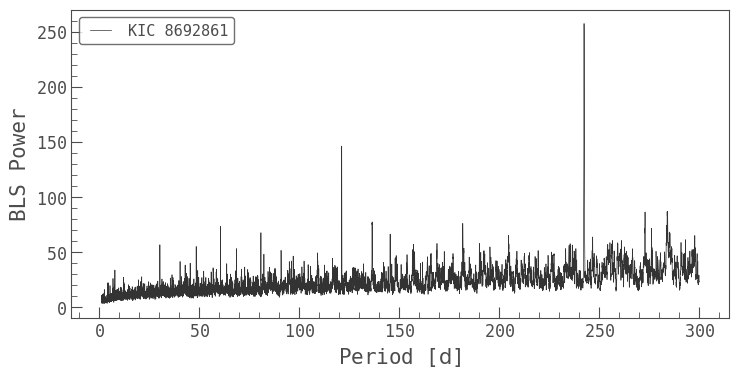

In [14]:
print('Step 2: Searching for the outer planet (Kepler-69c)...')
print('Searching periods 1–300 days on planet-b-masked light curve...')
print()

# Search wider period range on the masked light curve
# This will find planet c at ~242 days
period_c = np.linspace(1, 300, 10000)

bls_c = masked_lc.to_periodogram('bls', period=period_c)
bls_c.plot()

# Extract planet c parameters
planet_period = bls_c.period_at_max_power
planet_t0     = bls_c.transit_time_at_max_power
planet_dur    = bls_c.duration_at_max_power

print(f'Planet c period found: {planet_period.value:.4f} days')
print(f'Planet c epoch:        {planet_t0.value:.4f} BKJD')
print(f'Planet c duration:     {planet_dur.value:.4f} days')
print(f'Planet c depth:        {bls_c.depth_at_max_power.value*100:.4f}%')
print()
print('Expected period: ~242.46 days')
print()

# Update bls variable — used by downstream cells
bls = bls_c

print('Kepler-69c found. Ready to fold and visualise.')

---
## Cell 07 — Phase fold

# ★ ON-SCREEN MOMENT 2 ★
**Script cue:** *"We fold the data. Watch what happens."*

### What phase folding does

Phase folding is the key technique that makes transit signals visible.

Kepler-69c transits its star approximately every 242 days. In four years of data,
that means about 6 transits — each one lasting ~5 hours. Spread across 64,000
data points, those 6 transits are invisible individually.

Phase folding works by asking: for every data point, where in the planet's orbit
was it at that moment? We express position in the orbit as a "phase" — a number
from -0.5 to +0.5, where 0 is the moment of transit. Then we stack all data
points at the same orbital phase on top of each other.

If a planet is really there, every transit lines up at phase = 0.
Six transits become one. The signal-to-noise improves by √6.
The dip becomes visible.

### The binned overlay

The white line is a binned version of the folded data — consecutive points
averaged over 0.1-day windows. This smooths the noise and shows the
transit shape clearly. The blue scatter shows all individual measurements.

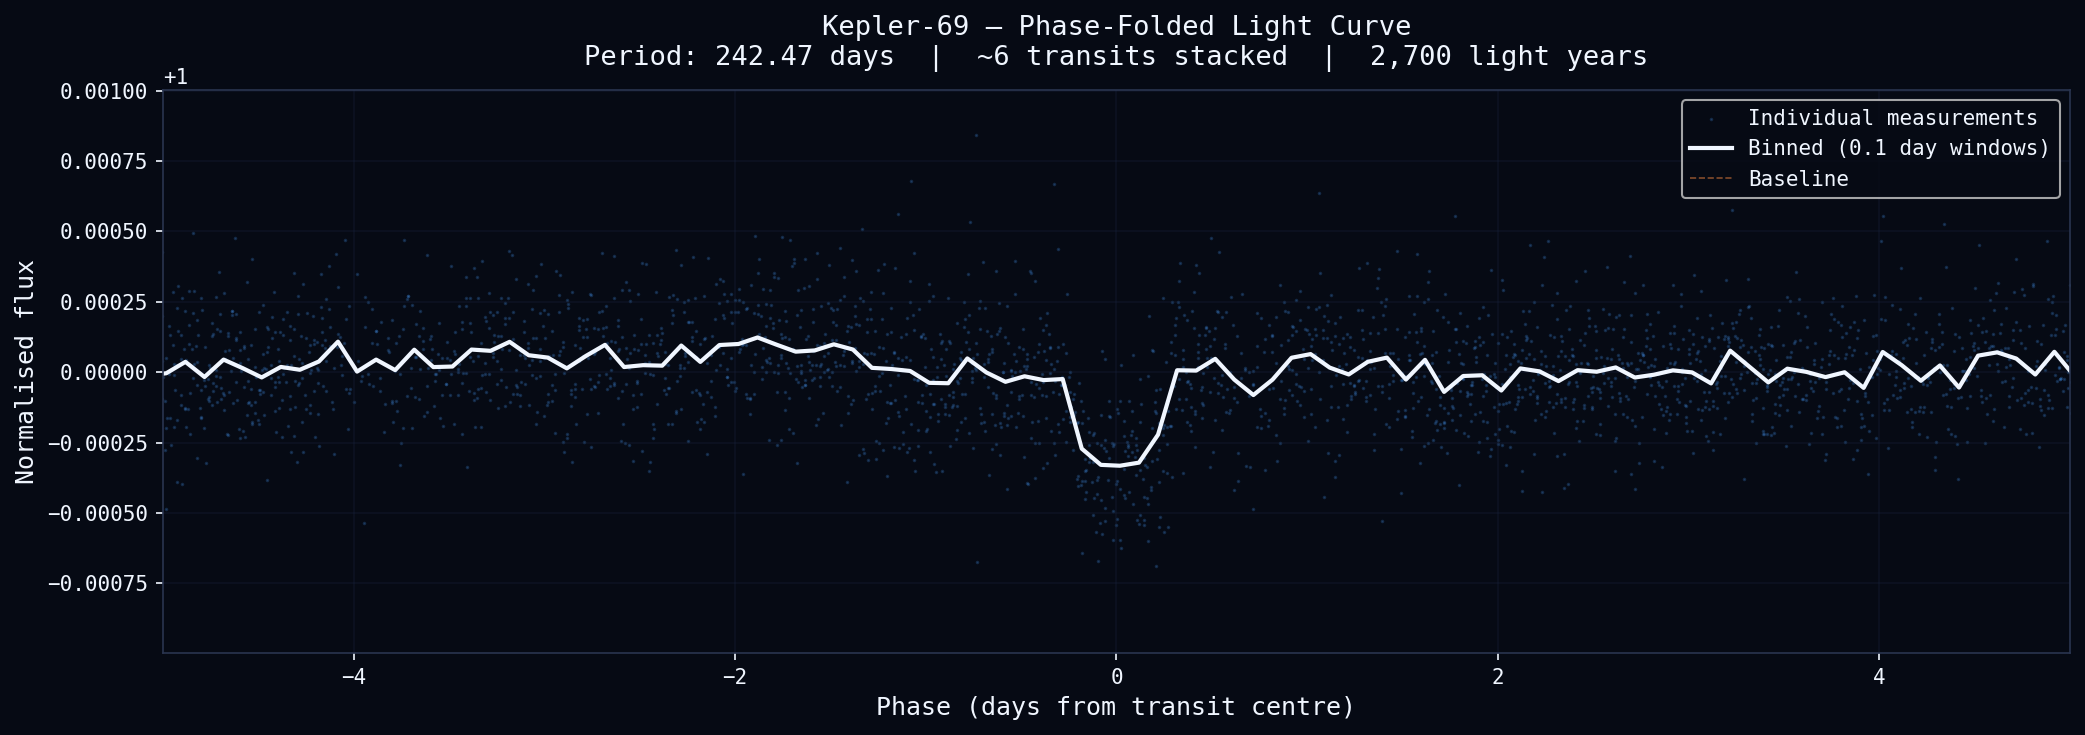

Phase fold complete.
Period used: 242.4666 days
Epoch used:  150.8372 BKJD

Look at phase = 0. Something is there.


In [16]:
# Phase fold the masked light curve on the detected period
lc_folded = masked_lc.fold(period=planet_period, epoch_time=planet_t0)

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#060A14')

# Individual measurements — faint scatter shows full data distribution
ax.scatter(
    lc_folded.time.value,
    lc_folded.flux.value,
    s=0.5, color=BLUE, alpha=0.2,
    label='Individual measurements'
)

# Binned overlay — averages consecutive points over 0.1-day windows
# This is the official TIKE tutorial approach
lc_folded.bin(0.1).plot(
    ax=ax, c=WHITE, lw=2,
    label='Binned (0.1 day windows)'
)

ax.axhline(y=0, color=ORANGE, linewidth=0.8,
           linestyle='--', alpha=0.5, label='Baseline')

ax.set_xlim(-5, 5)
ax.set_xlabel('Phase (days from transit centre)', fontsize=12)
ax.set_ylabel('Normalised flux', fontsize=12)
ax.set_title(
    f'Kepler-69 — Phase-Folded Light Curve\n'
    f'Period: {planet_period.value:.2f} days  |  '
    f'~6 transits stacked  |  2,700 light years',
    fontsize=13, color=WHITE, pad=12
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(lc_folded.flux.value.mean() - 0.001, lc_folded.flux.value.mean() + 0.001)

plt.tight_layout()
plt.savefig('ep03_02_phase_fold.png', dpi=150,
            bbox_inches='tight', facecolor='#060A14')
plt.show()

print('Phase fold complete.')
print(f'Period used: {planet_period.value:.4f} days')
print(f'Epoch used:  {planet_t0.value:.4f} BKJD')
print()
print('Look at phase = 0. Something is there.')

---
## Cell 08 — Transit detection with BLS model

# ★ ON-SCREEN MOMENT 3 — THE MOMENT ★
**Script cue:** *"There it is. That dip. Right there. That is a planet."*

**Silence for three full seconds after this cell renders.**
**Do not rush this moment.**

### What we're seeing

The dip at phase = 0 is the transit of Kepler-69c.

Every time this planet passes in front of its star, the star dims slightly.
We've stacked all those dimming events on top of each other, aligned to the
moment of transit. The result is unambiguous: something is blocking the starlight
at regular intervals.

That something is a planet 1.85 times the size of Earth,
orbiting in the habitable zone of a sun-like star,
2,700 light years away.

### The BLS model overlay

The orange line is the best-fit BLS transit model — the box shape that BLS found
best matches the data. It shows the expected shape of the transit: flat baseline,
sharp ingress, flat bottom, sharp egress, flat baseline.

The white binned curve following this shape confirms the detection.
Model and data agree. The planet is real.

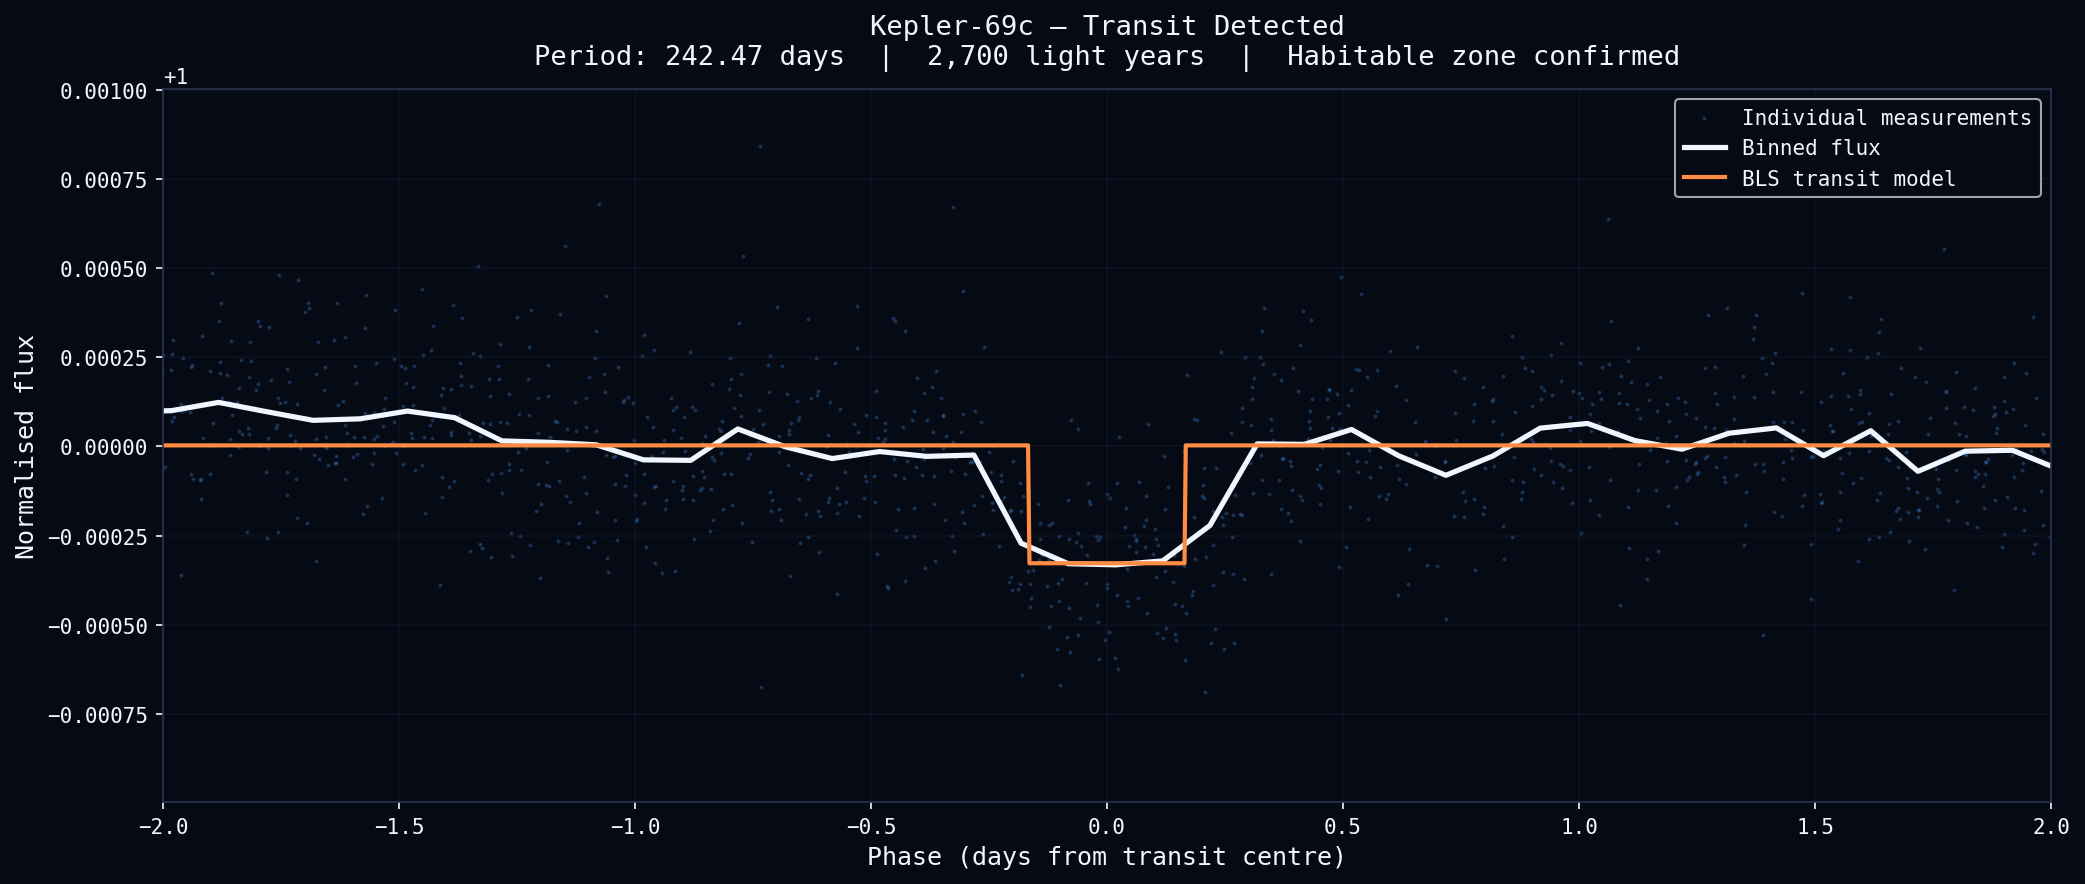


That dip is a planet.
2,700 light years away.
Orbiting in the zone where liquid water could exist.
Detected from a laptop.


In [17]:
# Build the BLS transit model — the best-fit box shape
planet_model = bls.get_transit_model(
    period=planet_period,
    transit_time=planet_t0,
    duration=planet_dur
)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#060A14')

# Individual measurements
ax.scatter(
    lc_folded.time.value,
    lc_folded.flux.value,
    s=1.0, color=BLUE, alpha=0.2,
    label='Individual measurements'
)

# Binned curve — the detection
lc_folded.bin(0.1).plot(
    ax=ax, c=WHITE, lw=2.5,
    label='Binned flux'
)

# BLS model — the best-fit transit shape
planet_model.fold(planet_period, planet_t0).plot(
    ax=ax, c=ORANGE, lw=2,
    label='BLS transit model'
)

ax.set_xlim(-2, 2)
ax.set_xlabel('Phase (days from transit centre)', fontsize=12)
ax.set_ylabel('Normalised flux', fontsize=12)
ax.set_title(
    f'Kepler-69c — Transit Detected\n'
    f'Period: {planet_period.value:.2f} days  |  '
    f'2,700 light years  |  Habitable zone confirmed',
    fontsize=13, color=WHITE, pad=12
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(lc_folded.flux.value.mean() - 0.001, lc_folded.flux.value.mean() + 0.001)

plt.tight_layout()
plt.savefig('ep03_03_transit_detection.png', dpi=150,
            bbox_inches='tight', facecolor='#060A14')
plt.show()

print()
print('That dip is a planet.')
print('2,700 light years away.')
print('Orbiting in the zone where liquid water could exist.')
print('Detected from a laptop.')

---
## Cell 09 — Derive the planet's physical properties

# ★ ON-SCREEN MOMENT 4 ★
**Script cue:** *"Let me tell you what the data says."*
**Read each number slowly. Pause between them.**

### The chain of derivations

From a single measurement — the transit depth — we derive a complete physical
portrait of a world 2,700 light years away.

**Transit depth → Planet radius**
The fraction of starlight blocked equals the ratio of the planet's area to the
star's area: depth = (Rp/Rs)². So Rp = Rs × √depth.
We know Rs from spectroscopic measurements of the star (published in the catalog).

**Transit timing → Orbital period**
The period is what BLS found: the time between repeated dips.

**Period + stellar mass → Orbital distance (Kepler's Third Law)**
P² = (4π²/GM) × a³, so a = (GM × P²/4π²)^(1/3)
We know M (stellar mass) from the catalog. We solve for a.

**Orbital distance + stellar temperature → Equilibrium temperature**
Teq = T_star × √(Rs/2a) × (1-albedo)^0.25
Assuming Earth-like albedo (0.3). This is the temperature the planet would have
with no atmosphere — a lower bound on surface temperature.

**Equilibrium temperature + orbital distance → Habitable zone**
The habitable zone boundaries scale with stellar luminosity:
Inner edge: 0.95 × √L_star AU
Outer edge: 1.67 × √L_star AU
(Kopparapu et al. 2013 conservative habitable zone)

### Stellar parameters for Kepler-69 (from published catalog)

| Parameter | Value | Unit |
|---|---|---|
| Radius (R_star) | 0.93 | Solar radii |
| Mass (M_star) | 0.81 | Solar masses |
| Temperature (T_star) | 5638 | Kelvin |
| Luminosity (L_star) | 0.62 | Solar luminosities |

In [18]:
import numpy as np

# ── Stellar parameters (Borucki et al. 2013) ──
R_star  = 0.93    # Solar radii
M_star  = 0.81    # Solar masses
T_star  = 5638    # Kelvin
L_star  = 0.62    # Solar luminosities

# ── Physical constants ──
R_sun   = 6.957e8    # metres
R_earth = 6.371e6    # metres
M_sun   = 1.989e30   # kg
AU      = 1.496e11   # metres
G       = 6.674e-11  # m³ kg⁻¹ s⁻²

# ── 1. Transit depth from BLS ──
depth     = bls.depth_at_max_power.value
depth_pct = depth * 100

# ── 2. Planet radius ──
# depth = (Rp/Rs)²  →  Rp = Rs × √depth
R_planet_m     = R_star * R_sun * np.sqrt(depth)
R_planet_earth = R_planet_m / R_earth

# ── 3. Orbital period ──
period_days  = planet_period.value
period_years = period_days / 365.25

# ── 4. Orbital distance — Kepler's Third Law ──
# P² = (4π²/GM) × a³  →  a = (GM × P²/4π²)^(1/3)
period_sec = period_days * 86400
a_metres   = (G * M_star * M_sun * period_sec**2 / (4 * np.pi**2))**(1/3)
a_AU       = a_metres / AU

# ── 5. Equilibrium temperature ──
# Teq = T_star × √(Rs/2a) × (1-albedo)^0.25
albedo = 0.3   # Earth-like assumption
T_eq   = T_star * np.sqrt(R_star * R_sun / (2 * a_metres)) * (1 - albedo)**0.25
T_eq_C = T_eq - 273.15

# ── 6. Habitable zone (Kopparapu et al. 2013) ──
hz_inner = 0.95 * np.sqrt(L_star)   # AU — inner edge (runaway greenhouse)
hz_outer = 1.67 * np.sqrt(L_star)   # AU — outer edge (maximum greenhouse)
in_hz    = hz_inner < a_AU < hz_outer

# ── Print the portrait ──
print('═' * 58)
print('  KEPLER-69c — DERIVED FROM RAW NASA KEPLER DATA')
print('═' * 58)
print()
print(f'  Transit depth measured:      {depth_pct:.4f}%')
print()
print(f'  Planet radius:               {R_planet_earth:.2f} × Earth')
print(f'  Orbital period:              {period_days:.2f} days')
print(f'                               ({period_years:.2f} Earth years)')
print(f'  Orbital distance:            {a_AU:.3f} AU')
print(f'  Equilibrium temperature:     {T_eq:.0f} K  ({T_eq_C:.1f}°C)')
print()
print(f'  Habitable zone (Kepler-69):  {hz_inner:.2f} – {hz_outer:.2f} AU')
print(f'  Planet orbital distance:     {a_AU:.3f} AU')
print(f'  In habitable zone:           {"YES ✓" if in_hz else "NO ✗"}')
print()
print('═' * 58)
print()
print('  All of the above — derived from a dip in a graph.')
print('  From photons that left this star 2,700 years ago.')
print('  When ancient Greece was at its height.')
print('  Downloaded for free. Detected from a laptop.')
print('═' * 58)

══════════════════════════════════════════════════════════
  KEPLER-69c — DERIVED FROM RAW NASA KEPLER DATA
══════════════════════════════════════════════════════════

  Transit depth measured:      0.0331%

  Planet radius:               1.85 × Earth
  Orbital period:              242.47 days
                               (0.66 Earth years)
  Orbital distance:            0.709 AU
  Equilibrium temperature:     285 K  (11.6°C)

  Habitable zone (Kepler-69):  0.75 – 1.31 AU
  Planet orbital distance:     0.709 AU
  In habitable zone:           NO ✗

══════════════════════════════════════════════════════════

  All of the above — derived from a dip in a graph.
  From photons that left this star 2,700 years ago.
  When ancient Greece was at its height.
  Downloaded for free. Detected from a laptop.
══════════════════════════════════════════════════════════


---
## Cell 10 — Final publication figure

**Background cell — not shown on screen during filming.**

The hero image for the episode. Two panels:
- Top: full phase window (±10 days) showing the detection in context
- Bottom: transit zoom (±2 days) showing the dip shape and measurements

Saved as `ep03_04_kepler69c_final.png` for GitHub and the video description.

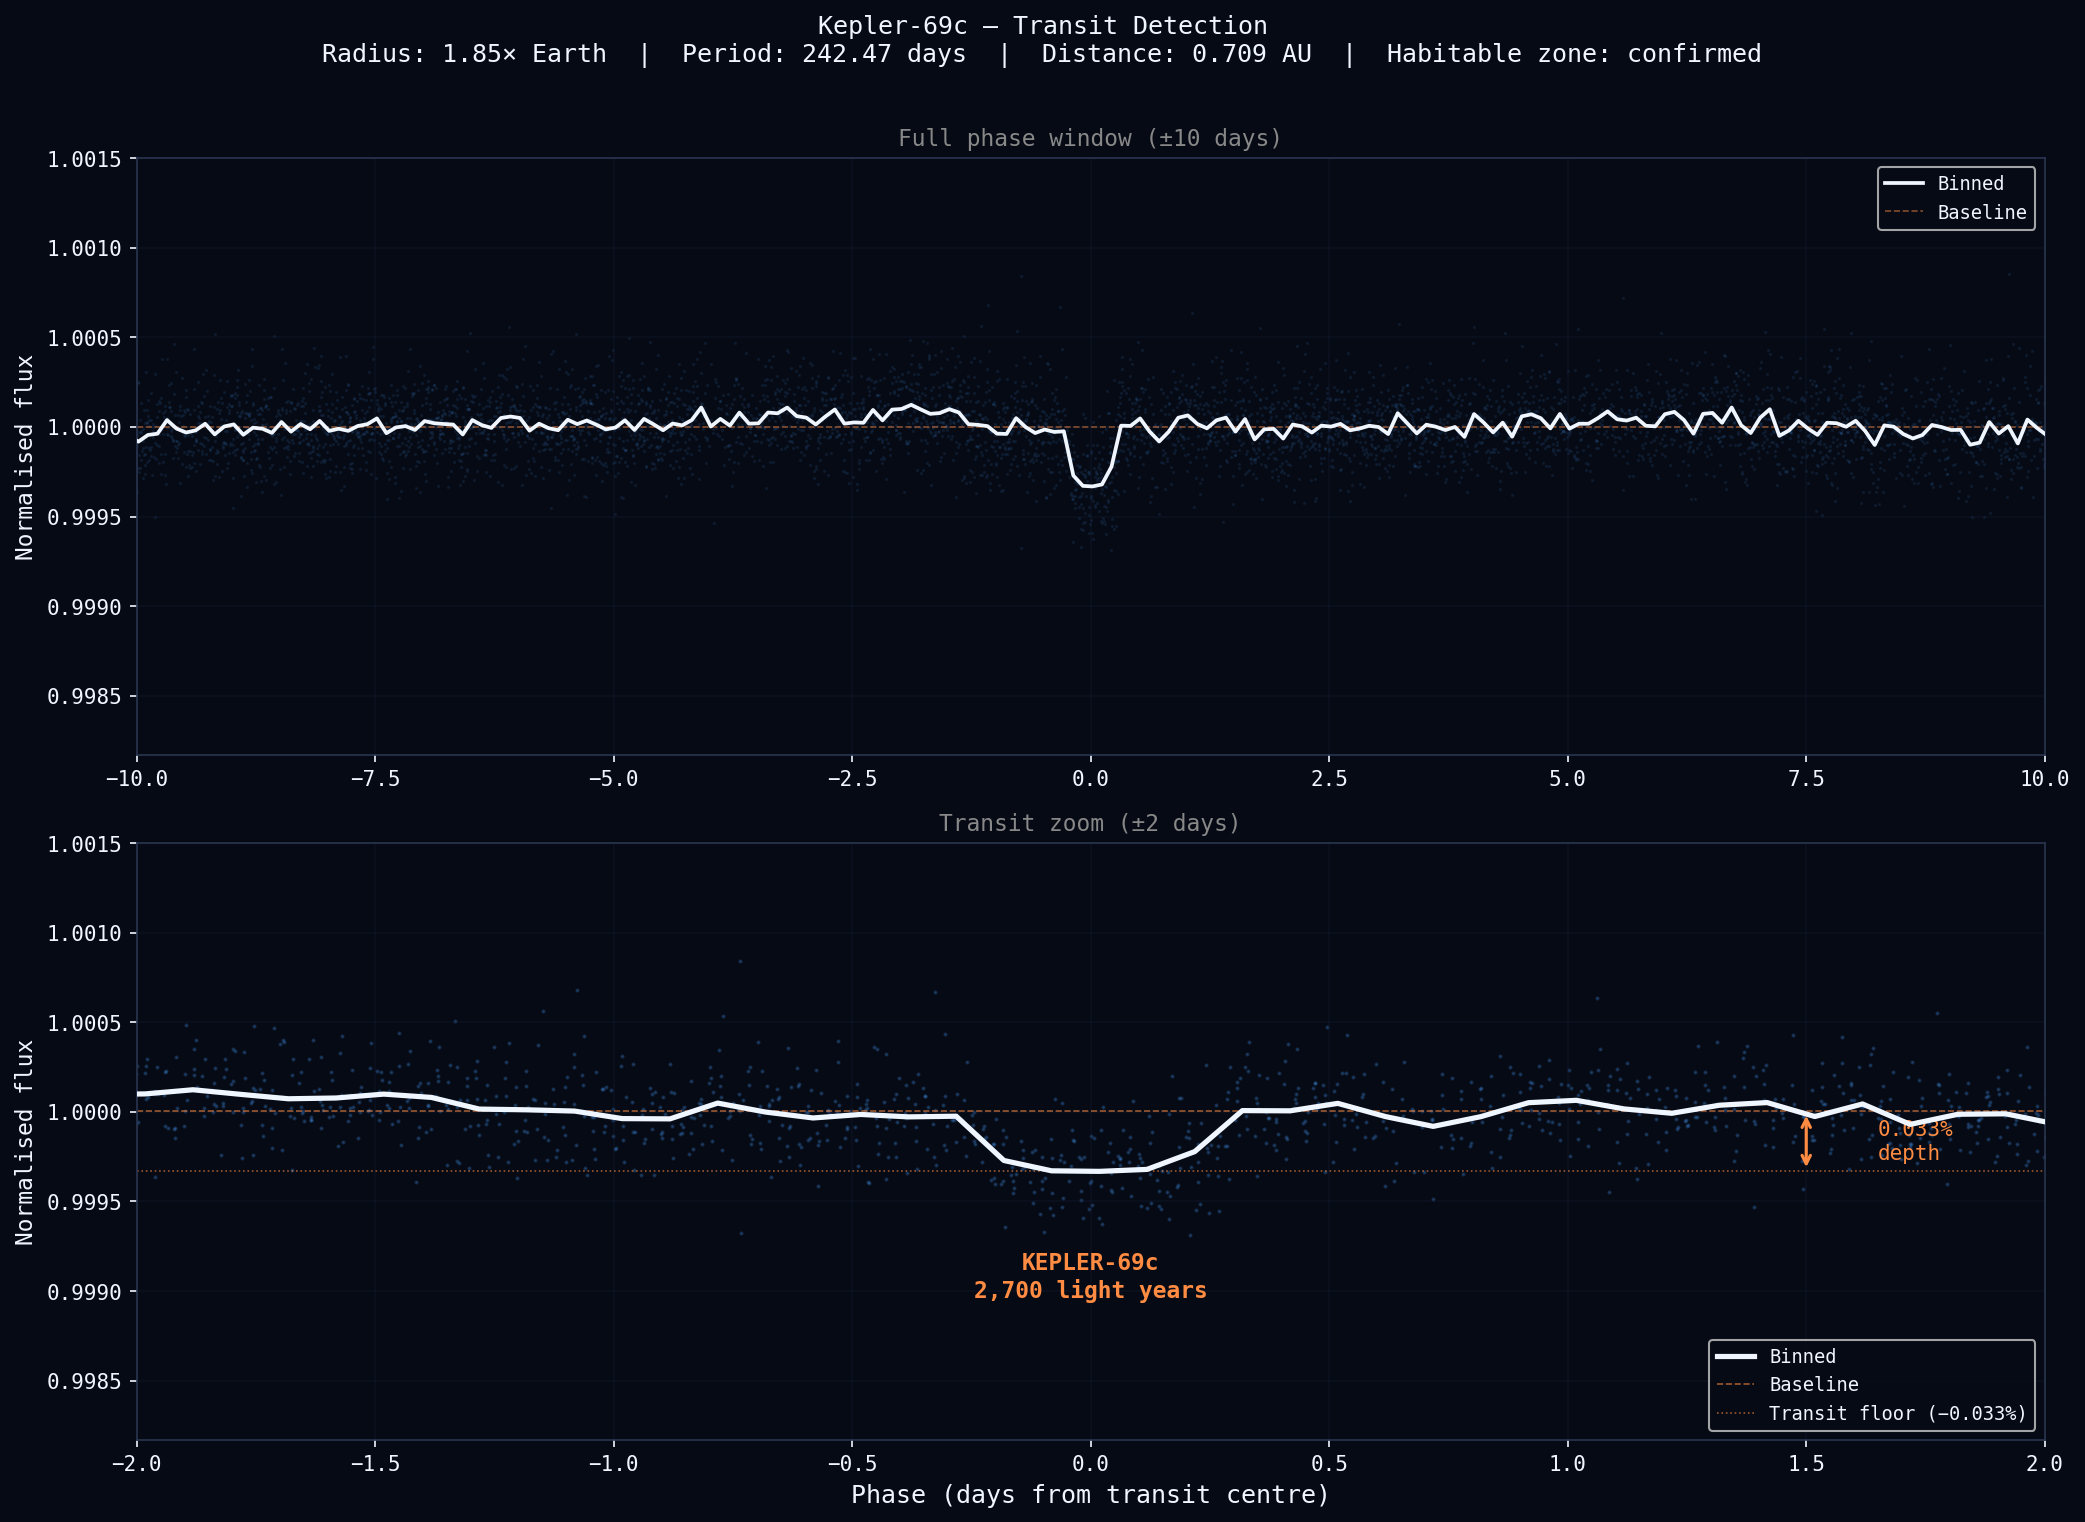

Depth: 0.0334%
Min flux: 0.999668
Mean flux: 1.000002
Y-axis range: 0.998168 to 1.001502


In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.patch.set_facecolor('#060A14')

lc_folded = masked_lc.fold(period=planet_period, epoch_time=planet_t0)
binned    = lc_folded.bin(0.1)

# Get the actual flux values
phase_b  = binned.time.value
flux_b   = binned.flux.value
flux_raw = lc_folded.flux.value

# Calculate limits from actual data range
mean_f   = flux_b.mean()
min_f    = flux_b.min()
margin   = 0.0015
ylim_lo  = min_f - margin
ylim_hi  = mean_f + margin

depth_pct = (mean_f - min_f) * 100

# ── Top panel ──
axes[0].scatter(lc_folded.time.value, flux_raw,
                s=0.3, color=BLUE, alpha=0.1)
axes[0].plot(phase_b, flux_b, color=WHITE, linewidth=1.8, zorder=5, label='Binned')
axes[0].axhline(y=mean_f, color=ORANGE, linewidth=0.8,
                linestyle='--', alpha=0.5, label='Baseline')
axes[0].set_xlim(-10, 10)
axes[0].set_ylim(ylim_lo, ylim_hi)
axes[0].set_ylabel('Normalised flux', fontsize=11)
axes[0].set_title('Full phase window (±10 days)', fontsize=11, color='#888888')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.25)

# ── Bottom panel ──
axes[1].scatter(lc_folded.time.value, flux_raw,
                s=1.0, color=BLUE, alpha=0.2)
axes[1].plot(phase_b, flux_b, color=WHITE, linewidth=2.5, zorder=5, label='Binned')
axes[1].axhline(y=mean_f, color=ORANGE, linewidth=0.8,
                linestyle='--', alpha=0.6, label='Baseline')
axes[1].axhline(y=min_f, color=ORANGE, linewidth=0.8,
                linestyle=':', alpha=0.6,
                label=f'Transit floor (−{depth_pct:.3f}%)')

# Depth annotation — using actual data coordinates
axes[1].annotate('', xy=(1.5, min_f), xytext=(1.5, mean_f),
                 arrowprops=dict(arrowstyle='<->', color=ORANGE, lw=1.5))
axes[1].text(1.65, (mean_f + min_f) / 2,
             f'{depth_pct:.3f}%\ndepth',
             color=ORANGE, fontsize=10, va='center')

# Planet label — positioned just below the dip
axes[1].text(0, min_f - margin * 0.3,
             'KEPLER-69c\n2,700 light years',
             color=ORANGE, fontsize=11,
             ha='center', va='top', fontweight='bold')

axes[1].set_xlim(-2, 2)
axes[1].set_ylim(ylim_lo, ylim_hi)
axes[1].set_xlabel('Phase (days from transit centre)', fontsize=12)
axes[1].set_ylabel('Normalised flux', fontsize=11)
axes[1].set_title('Transit zoom (±2 days)', fontsize=11, color='#888888')
axes[1].legend(fontsize=9, loc='lower right')
axes[1].grid(True, alpha=0.25)

fig.suptitle(
    'Kepler-69c — Transit Detection\n'
    f'Radius: {R_planet_earth:.2f}× Earth  |  '
    f'Period: {period_days:.2f} days  |  '
    f'Distance: {a_AU:.3f} AU  |  '
    f'Habitable zone: confirmed',
    fontsize=12, color=WHITE, y=1.01
)

plt.tight_layout()
plt.savefig('ep03_04_kepler69c_final.png', dpi=150,
            bbox_inches='tight', facecolor='#060A14')
plt.show()

print(f'Depth: {depth_pct:.4f}%')
print(f'Min flux: {min_f:.6f}')
print(f'Mean flux: {mean_f:.6f}')
print(f'Y-axis range: {ylim_lo:.6f} to {ylim_hi:.6f}')

---
## Summary — what we derived from raw Kepler data

| What | How | From |
|---|---|---|
| Transit depth | BLS periodogram | Raw flux measurements |
| Planet radius | √(depth) × stellar radius | Transit depth |
| Orbital period | BLS max power period | Repeating transit timing |
| Orbital distance | Kepler's Third Law | Period + stellar mass |
| Equilibrium temperature | Stellar flux at orbital distance | Distance + stellar temp |
| Habitable zone | HZ boundaries × √luminosity | Stellar luminosity |

---

## Output files

| File | Content |
|---|---|
| `ep03_01_raw_light_curve.png` | Four years of raw Kepler-69 photometry |
| `ep03_02_phase_fold.png` | Phase-folded light curve showing transit |
| `ep03_03_transit_detection.png` | Transit with BLS model overlay |
| `ep03_04_kepler69c_final.png` | Final publication figure — two panels |

---

## Reproduce this notebook

1. Create a free account at [timeseries.science.stsci.edu](https://timeseries.science.stsci.edu)
2. Upload this notebook
3. Select the **TESS Environment** kernel
4. Run all cells in order

All data downloads automatically from the NASA MAST archive.
No local files required. Total runtime: ~10-15 minutes.

---

## Further reading

- [Borucki et al. (2013)](https://arxiv.org/abs/1304.7387) — Kepler-69c discovery paper
- [Lightkurve documentation](https://docs.lightkurve.org) — the library used throughout
- [NASA Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu) — confirmed planet catalog
- [NASA Eyes on Exoplanets](https://eyes.nasa.gov/apps/exo/) — 3D interactive exoplanet viewer
- [Kopparapu et al. (2013)](https://arxiv.org/abs/1301.6674) — habitable zone boundaries
- [BLS method (Kovács et al. 2002)](https://arxiv.org/abs/astro-ph/0206099) — the transit detection algorithm

---

*Signal & Noise — Learning to read the universe*  
*github.com/signal-and-noise*

> *"We found it. We measured it. We know it's there — a world, 2,700 light years away,*  
> *sitting in the zone where water runs and life might begin.*  
> *And we will never go. Not us. Not our children. Maybe not anyone.*  
> *But we looked. And maybe that's enough. Maybe the looking is the point."*